In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import librosa
import IPython.display as ipd
import librosa.display
from google.colab import drive
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/IRMAS-TrainingData.zip /content/
!unzip -q /content/IRMAS-TrainingData.zip -d /content/dataset

In [3]:
!cp /content/drive/MyDrive/IRMAS-TestingData-Part1.zip /content/
!unzip -q /content/IRMAS-TestingData-Part1.zip -d /content/dataset

In [33]:
data_path = 'dataset/IRMAS-TrainingData'
classes = sorted({
    d for d in os.listdir(data_path)
    if os.path.isdir(os.path.join(data_path, d))
})
class_to_idx = {cls: i for i, cls in enumerate(classes)}

data = []
for cls in classes:
    cls_dir = os.path.join(data_path, cls)
    for file in os.listdir(cls_dir):
        if file.endswith('.wav'):
            data.append({'path': os.path.join(cls_dir, file), 'label_int': class_to_idx[cls]})

df = pd.DataFrame(data)

AST expects audio at 16 kHz and exactly 10secs.

In [42]:
import torch
import torchaudio
from transformers import ASTFeatureExtractor

feature_extractor = ASTFeatureExtractor()

class IRMASDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        audio_path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        waveform, sr = torchaudio.load(audio_path)
        if sr != 16000:
            resampler = torchaudio.transforms.Resample(sr, 16000)
            waveform = resampler(waveform)

        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        inputs = feature_extractor(waveform.squeeze().numpy(), sampling_rate=16000, return_tensors="pt")
        return {
            "input_values": inputs['input_values'].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.float)
        }

In [11]:
from transformers import ASTForAudioClassification

model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=len(classes),
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True
)

model.to("cuda")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([11, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([11])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=T

In [7]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00


In [43]:
import evaluate
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
#metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    probs = 1 / (1+np.exp(-predictions))
    predictions_binary = (probs > 0.5).astype(float)
    return {
        "accuracy": accuracy_score(labels, predictions_binary),
        "f1": f1_score(labels, predictions_binary, average="samples")
    }

In [50]:
from transformers import TrainingArguments, Trainer
drive_path = "/content/drive/MyDrive/ast_instrument_model"
training_args = TrainingArguments(
    output_dir=drive_path,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=5e-5,
    fp16=True,
    dataloader_num_workers=1,
    #logging_steps=150,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [45]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_int"]
)
def to_one_hot(label_idx):
  vec = np.zeros(len(classes), dtype=np.float32)
  vec[label_idx] = 1.0
  return vec
train_df["label"] = train_df["label_int"].apply(to_one_hot)
val_df["label"] = val_df["label_int"].apply(to_one_hot)


In [46]:
train_dataset = IRMASDataset(train_df)
val_dataset = IRMASDataset(val_df)

In [51]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [52]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.490610,0.091292,0.757644,0.766592
2,0.230564,0.067997,0.832215,0.842158
3,0.113487,0.080093,0.826249,0.835695
4,0.049880,0.073081,0.864280,0.868755
5,0.025306,0.068357,0.869500,0.877455


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=840, training_loss=0.18196913003921508, metrics={'train_runtime': 2398.5858, 'train_samples_per_second': 11.182, 'train_steps_per_second': 0.35, 'total_flos': 1.8180817444247962e+18, 'train_loss': 0.18196913003921508, 'epoch': 5.0})

In [53]:
history = trainer.state.log_history

In [54]:
train_loss = [log["loss"] for log in history if "loss" in log]
val_loss = [log["eval_loss"] for log in history if "eval_loss" in log]
val_acc = [log["eval_accuracy"] for log in history if "eval_accuracy" in log]
epochs = range(1, len(val_loss) + 1)

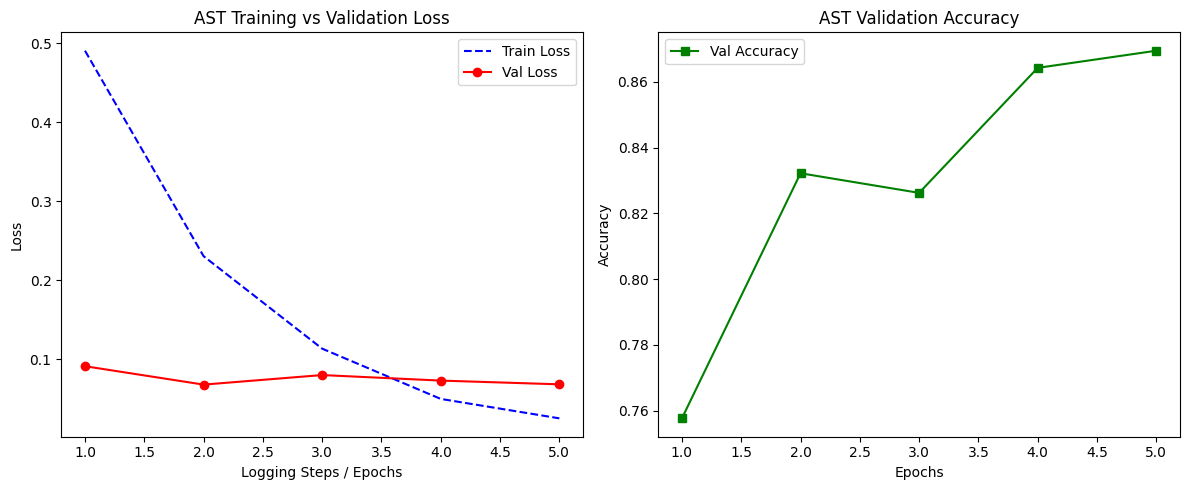

In [55]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss', color='blue', linestyle='--')
plt.plot(epochs, val_loss, label='Val Loss', color='red', marker='o')
plt.title('AST Training vs Validation Loss')
plt.xlabel('Logging Steps / Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, val_acc, label='Val Accuracy', color='green', marker='s')
plt.title('AST Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
import os
import glob
import numpy as np

test_path = "/content/dataset/IRMAS-TestingData-Part1/Part1"
test_files = glob.glob(os.path.join(test_path, "*.wav"))

label2id = {label: i for i, label in enumerate(classes)}
num_classes = len(classes)

final_test_files = []
final_test_labels = []

for f in test_files:
    txt_file = f.replace(".wav", ".txt")
    if os.path.exists(txt_file):
        with open(txt_file, 'r') as t:
            codes = [line.strip() for line in t.readlines() if line.strip() in label2id]

            if codes:
                label_vector = np.zeros(num_classes, dtype=np.float32)
                for code in codes:
                    label_vector[label2id[code]] = 1.0

                final_test_files.append(f)
                final_test_labels.append(label_vector)

print(f"Success! Loaded {len(final_test_files)} files with multi-label support.")

Success! Loaded 807 files with multi-label support.


In [64]:
from sklearn.metrics import classification_report, f1_score

test_df = pd.DataFrame({
    'path': final_test_files,
    'label': final_test_labels
})

test_dataset = IRMASDataset(test_df)

test_results = trainer.predict(test_dataset)
logits = test_results.predictions

probs = 1 / (1 + np.exp(-logits))

predicted_labels = (probs > 0.3).astype(float)
true_labels = np.array(final_test_labels)

sample_f1 = f1_score(true_labels, predicted_labels, average='samples')

print(f"✅ Multi-label Sample F1 Score: {sample_f1 * 100:.2f}%")

print(classification_report(true_labels, predicted_labels, target_names=classes))

✅ Multi-label Sample F1 Score: 66.14%
              precision    recall  f1-score   support

         cel       0.00      0.00      0.00        26
         cla       0.17      0.12      0.14         8
         flu       0.92      0.82      0.87        28
         gac       0.94      0.46      0.62       145
         gel       0.81      0.31      0.45       241
         org       0.92      0.40      0.55        91
         pia       0.97      0.28      0.44       367
         sax       0.86      0.87      0.87       167
         tru       0.59      0.61      0.60        79
         vio       0.74      0.39      0.51        51
         voi       0.99      0.93      0.96       229

   micro avg       0.87      0.51      0.64      1432
   macro avg       0.72      0.47      0.55      1432
weighted avg       0.88      0.51      0.61      1432
 samples avg       0.87      0.57      0.66      1432



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


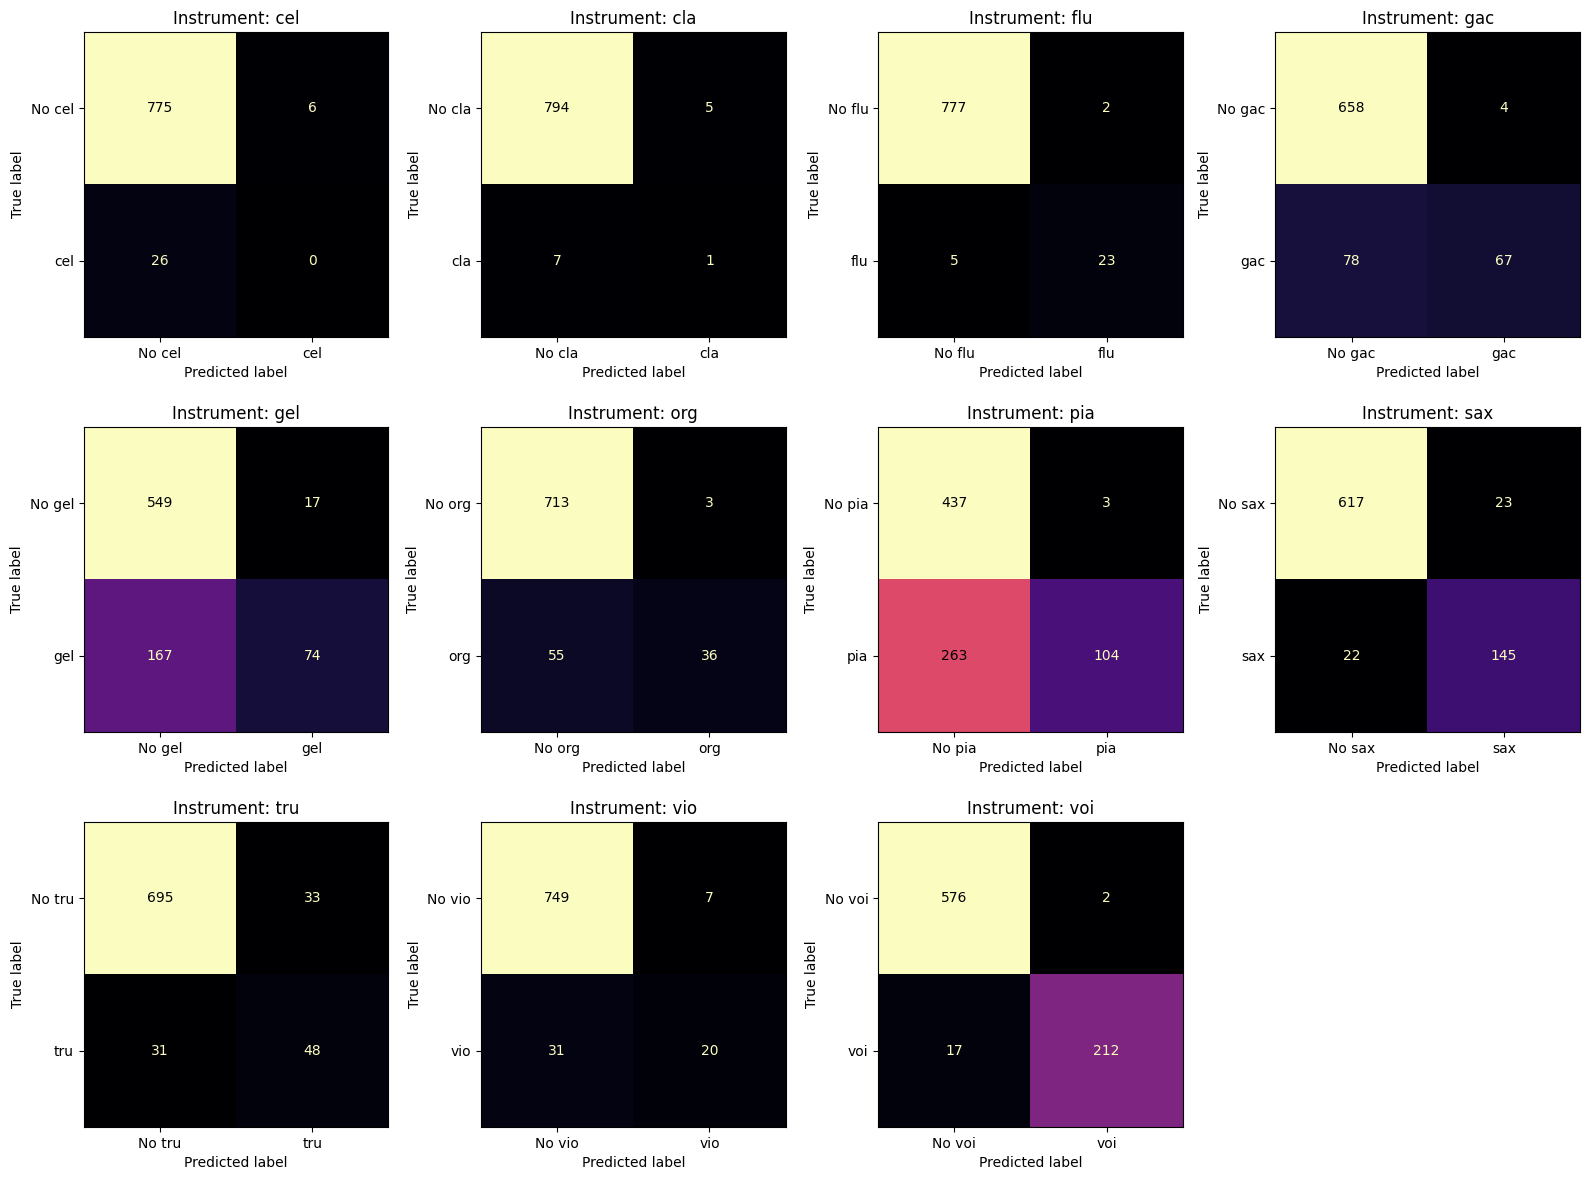

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

mcm = multilabel_confusion_matrix(true_labels, predicted_labels)

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
axes = axes.ravel()

for i in range(len(classes)):
    disp = ConfusionMatrixDisplay(confusion_matrix=mcm[i], display_labels=[f"No {classes[i]}", classes[i]])
    disp.plot(ax=axes[i], cmap='magma', colorbar=False)
    axes[i].set_title(f"Instrument: {classes[i]}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

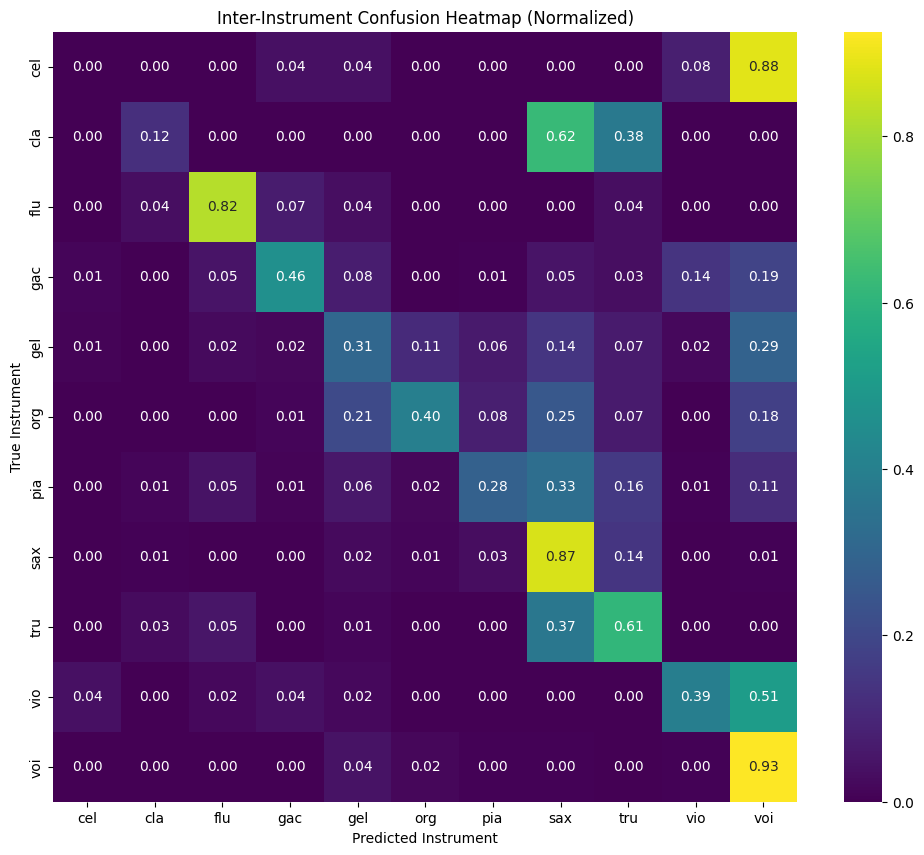

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

confusion_data = np.dot(true_labels.T, predicted_labels)

confusion_norm = confusion_data / true_labels.sum(axis=0)[:, None]

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_norm, annot=True, fmt=".2f", xticklabels=classes, yticklabels=classes, cmap="viridis")
plt.title("Inter-Instrument Confusion Heatmap (Normalized)")
plt.ylabel("True Instrument")
plt.xlabel("Predicted Instrument")
plt.show()

In [67]:
from sklearn.metrics import classification_report
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=classes,
    zero_division=0
))

              precision    recall  f1-score   support

         cel       0.00      0.00      0.00        26
         cla       0.17      0.12      0.14         8
         flu       0.92      0.82      0.87        28
         gac       0.94      0.46      0.62       145
         gel       0.81      0.31      0.45       241
         org       0.92      0.40      0.55        91
         pia       0.97      0.28      0.44       367
         sax       0.86      0.87      0.87       167
         tru       0.59      0.61      0.60        79
         vio       0.74      0.39      0.51        51
         voi       0.99      0.93      0.96       229

   micro avg       0.87      0.51      0.64      1432
   macro avg       0.72      0.47      0.55      1432
weighted avg       0.88      0.51      0.61      1432
 samples avg       0.87      0.57      0.66      1432

